#  Использование одномерных сверток в PyTorch

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
* https://pytorch.org/docs/stable/generated/torch.nn.MaxPool1d.html#torch.nn.MaxPool1d
* https://wandb.ai/wandb_fc/wb-tutorials/reports/Tutorial-Text-Classification-Using-CNNs--Vmlldzo0NTIxNDI5
* https://machinelearningmastery.com/how-to-develop-convolutional-neural-network-models-for-time-series-forecasting/

## Задачи для совместного разбора

In [1]:
# Используемые библиотеки
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from collections import Counter
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

1\. Изучите принцип работы одномерных сверточных слоев в `torch`

![1d conv](https://raw.githubusercontent.com/krzjoa/krzjoa.github.io/master/assets/img/2020-10-03-ts-and-torch-1/conv1d.gif)

![conv1d](https://www.macnica.co.jp/business/ai/blog/files/image5_2.png)

In [2]:
conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=0, bias=False)

In [3]:
# Фильтр
with torch.no_grad():
    conv.weight.data = torch.tensor([[[1.0, 2.0, -1.0]]])

In [4]:
# Параметры
"""batch_size = 1
sequence_length = 5"""

'batch_size = 1\nsequence_length = 5'

In [5]:
# Входной сигнал
input_data = torch.tensor([[[1.0, 3.0, 2.0, 4.0, 1.0]]]); input_data.shape

torch.Size([1, 1, 5])

In [6]:
# Свёртка
output = conv(input_data); output.shape, output

(torch.Size([1, 1, 3]),
 tensor([[[5., 3., 9.]]], grad_fn=<ConvolutionBackward0>))

In [7]:
# Фильтр [1, 2, -1] по [1, 3, 2, 4, 1]
# 1*1 + 2*3 + (-1)*2 = 1 + 6 - 2 = 5
# 1*3 + 2*2 + (-1)*4 = 3 + 4 - 4 = 3
# 1*2 + 2*4 + (-1)*1 = 2 + 8 - 1 = 9
# [5, 3, 9]

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите данные из файла `ts.csv`. Используя модель, состоящую из одного одномерного сверточного слоя, решите задачу предсказания $y_t$ по `k` предыдущим точкам временного ряда $x_{t-k}...x_{t-1}$. Исследуйте значения $k\in[1, 7]$. Для каждого $k$ выведите на экран итоговое значение функции потерь и веса ядра свертки. Визуализируйте исходный временной ряд и полученные прогнозы.

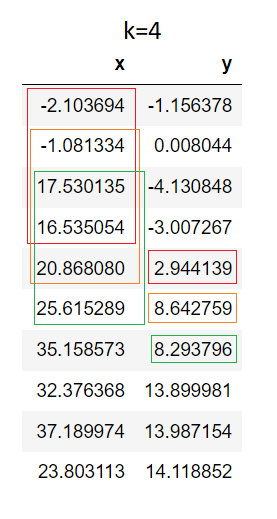
- [ ] Проверено на семинаре

In [8]:
data = pd.read_csv('ts.csv'); data.head()

,x,y
0,-2.103694,-1.156378
1,-1.081334,0.008044
2,17.530135,-4.130848
3,16.535054,-3.007267
4,20.868080,2.944139


In [9]:
x_data = data['x'].values
y_data = data['y'].values; len(x_data)

1005

In [10]:
# Масштабирование без утечки: scaler обучается только на первых 80% временного ряда.
raw_train_end = int(0.8 * len(x_data))

scaler_x = StandardScaler().fit(x_data[:raw_train_end].reshape(-1, 1))
scaler_y = StandardScaler().fit(y_data[:raw_train_end].reshape(-1, 1))

x_scaled = scaler_x.transform(x_data.reshape(-1, 1)).flatten()
y_scaled = scaler_y.transform(y_data.reshape(-1, 1)).flatten()

print(f'Scaler fit: первые {raw_train_end} из {len(x_data)} точек (только train-часть)')

Scaler fit: первые 804 из 1005 точек (только train-часть)


In [11]:
def create_dataset(x, y, k): # dataset с окном k
    X, Y = [], []
    for i in range(k, len(x)):
        X.append(x[i-k:i])
        Y.append(y[i])
    return torch.FloatTensor(X), torch.FloatTensor(Y)

In [12]:
class Conv1DModel(nn.Module): # Модель одномерной свертки
    def __init__(self, k):
        super(Conv1DModel, self).__init__()
        self.conv1d = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=k,
            stride=1,
            padding=0,
            bias=True
        )

    def forward(self, x):
        # x shape: (batch_size, k)
        x = x.unsqueeze(1)     # (batch_size, 1, k)
        x = self.conv1d(x)     # (batch_size, 1, 1)
        x = x.squeeze(-1)      # (batch_size, 1)
        x = x.squeeze(-1)      # (batch_size)
        return x


Исследование для k = 1


/tmp/ipykernel_4059/411932904.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  return torch.FloatTensor(X), torch.FloatTensor(Y)


Epoch [0/500], Loss: 0.091301
Epoch [100/500], Loss: 0.039184
Epoch [200/500], Loss: 0.039182
Epoch [300/500], Loss: 0.039182
Epoch [400/500], Loss: 0.039182
Финальные потери:
Train Loss: 0.039182
Test Loss: 0.031991
Веса ядра свертки: [0.97923404]
Смещение (bias): 0.000938

Исследование для k = 2
Epoch [0/500], Loss: 1.622444
Epoch [100/500], Loss: 0.058409
Epoch [200/500], Loss: 0.045606
Epoch [300/500], Loss: 0.035790
Epoch [400/500], Loss: 0.029524
Финальные потери:
Train Loss: 0.026143
Test Loss: 0.024234
Веса ядра свертки: [0.40978274 0.59629625]
Смещение (bias): 0.001166

Исследование для k = 3
Epoch [0/500], Loss: 0.318674
Epoch [100/500], Loss: 0.044670
Epoch [200/500], Loss: 0.020561
Epoch [300/500], Loss: 0.017253
Epoch [400/500], Loss: 0.016951
Финальные потери:
Train Loss: 0.016937
Test Loss: 0.014389
Веса ядра свертки: [-0.19062139  0.44405547  0.73706096]
Смещение (bias): 0.001522

Исследование для k = 4
Epoch [0/500], Loss: 0.527334
Epoch [100/500], Loss: 0.017301
Epoch

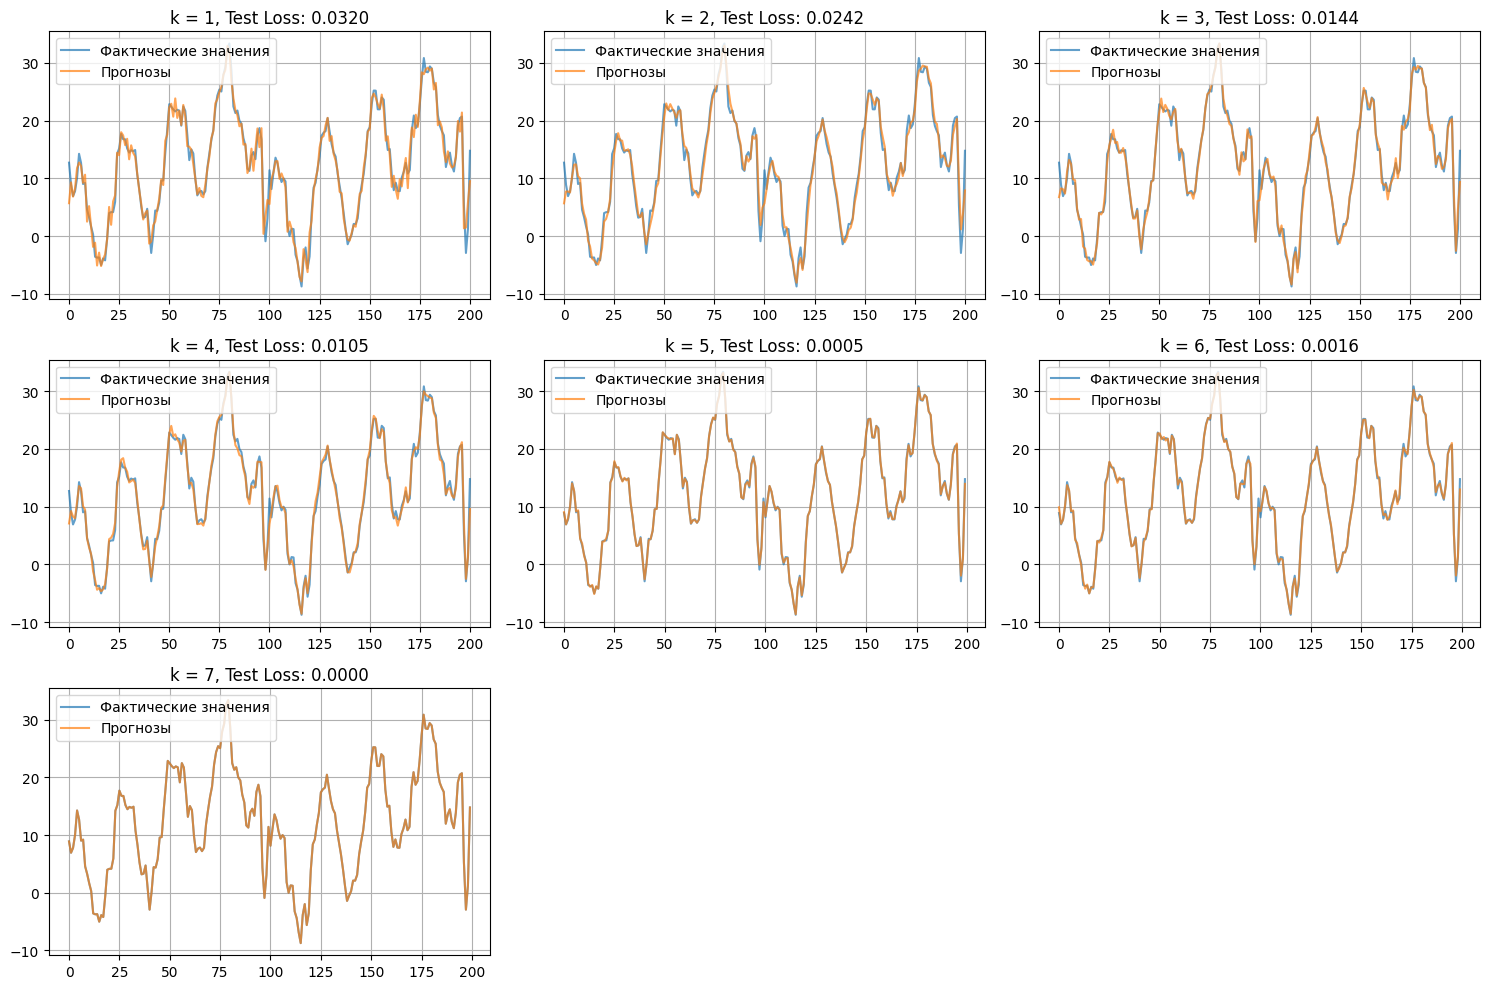

In [13]:
results = {}
k_values = range(1, 8) # сразными k

plt.figure(figsize=(15, 10))
for idx, k in enumerate(k_values):
    print(f"\n{'='*50}")
    print(f"Исследование для k = {k}")
    X, Y = create_dataset(x_scaled, y_scaled, k)
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    Y_train, Y_test = Y[:train_size], Y[train_size:]
    model = Conv1DModel(k)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    epochs = 500
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train)
        loss = criterion(outputs, Y_train) # разница между предсказанием нейронной сети и истинными метками

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 100 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

    model.eval()
    with torch.no_grad():
        train_pred = model(X_train)
        test_pred = model(X_test)

        train_loss = criterion(train_pred, Y_train)
        test_loss = criterion(test_pred, Y_test)

        print(f"Финальные потери:")
        print(f"Train Loss: {train_loss:.6f}")
        print(f"Test Loss: {test_loss:.6f}")

        # Получение весов ядра
        kernel_weights = model.conv1d.weight.data.numpy().flatten()
        bias = model.conv1d.bias.data.numpy().flatten()[0]

        print(f"Веса ядра свертки: {kernel_weights}")
        print(f"Смещение (bias): {bias:.6f}")

    results[k] = {
        'model': model,
        'train_loss': train_loss.item(),
        'test_loss': test_loss.item(),
        'kernel_weights': kernel_weights,
        'bias': bias,
        'predictions': test_pred.numpy(),
        'actual': Y_test.numpy()
    }

    plt.subplot(3, 3, idx + 1)
    actual_original = scaler_y.inverse_transform(Y_test.reshape(-1, 1)).flatten()
    pred_original = scaler_y.inverse_transform(test_pred.numpy().reshape(-1, 1)).flatten()
    plt.plot(actual_original, label='Фактические значения', alpha=0.7)
    plt.plot(pred_original, label='Прогнозы', alpha=0.7)
    plt.title(f'k = {k}, Test Loss: {test_loss:.4f}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
print(f"{'='*60}")
print(f"{'k':<3} {'Train Loss':<12} {'Test Loss':<12} {'Kernel Weights'}")
print(f"{'-'*60}")

for k in k_values:
    result = results[k]
    weights_str = ' '.join([f'{w:.3f}' for w in result['kernel_weights']])
    print(f"{k:<3} {result['train_loss']:<12.6f} {result['test_loss']:<12.6f} [{weights_str}]")

k   Train Loss   Test Loss    Kernel Weights
------------------------------------------------------------
1   0.039182     0.031991     [0.979]
2   0.026143     0.024234     [0.410 0.596]
3   0.016937     0.014389     [-0.191 0.444 0.737]
4   0.010629     0.010544     [-0.175 -0.051 0.484 0.715]
5   0.000605     0.000466     [0.218 -0.364 -0.058 0.453 0.745]
6   0.002020     0.001620     [0.037 0.142 -0.315 -0.049 0.421 0.760]
7   0.000000     0.000000     [-0.000 -0.000 0.250 -0.374 -0.125 0.500 0.747]


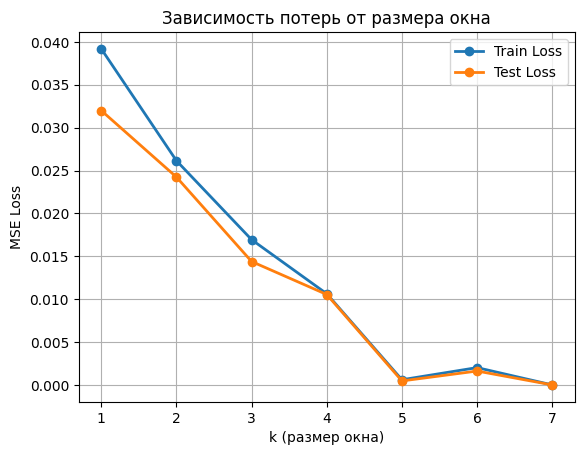

In [15]:
train_losses = [results[k]['train_loss'] for k in k_values]
test_losses = [results[k]['test_loss'] for k in k_values]

plt.plot(k_values, train_losses, 'o-', label='Train Loss', linewidth=2)
plt.plot(k_values, test_losses, 'o-', label='Test Loss', linewidth=2)
plt.xlabel('k (размер окна)')
plt.ylabel('MSE Loss')
plt.title('Зависимость потерь от размера окна')
plt.legend()
plt.grid(True)

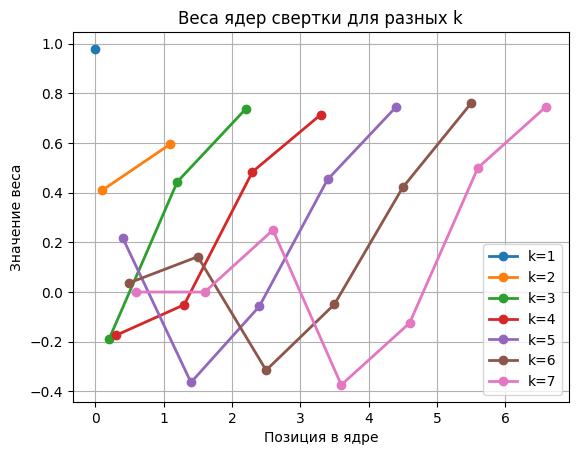

In [16]:
for k in k_values:
    weights = results[k]['kernel_weights']
    x_positions = np.arange(len(weights)) + (k - min(k_values)) * 0.1
    plt.plot(x_positions, weights, 'o-', label=f'k={k}', linewidth=2)

plt.xlabel('Позиция в ядре')
plt.ylabel('Значение веса')
plt.title('Веса ядер свертки для разных k')
plt.legend()
plt.grid(True)

In [17]:
best_k = min(k_values, key=lambda k: results[k]['test_loss'])
best_result = results[best_k]

print(f"\n{'='*50}")
print(f"ЛУЧШАЯ МОДЕЛЬ: k = {best_k}")
print(f"{'='*50}")
print(f"Test Loss: {best_result['test_loss']:.6f}")
print(f"Веса ядра: {best_result['kernel_weights']}")
print(f"Смещение: {best_result['bias']:.6f}")


ЛУЧШАЯ МОДЕЛЬ: k = 7
Test Loss: 0.000000
Веса ядра: [-1.6324209e-05 -2.0006916e-04  2.4961376e-01 -3.7431487e-01
 -1.2498630e-01  5.0037444e-01  7.4721503e-01]
Смещение: 0.004190


In [18]:
# Полные предсказания для лучшей модели
X_full, Y_full = create_dataset(x_scaled, y_scaled, best_k)
with torch.no_grad():
    full_predictions = results[best_k]['model'](X_full).numpy()

In [19]:
# Восстановление оригинального масштаба
full_predictions_original = scaler_y.inverse_transform(full_predictions.reshape(-1, 1)).flatten()
y_original = scaler_y.inverse_transform(y_scaled[best_k:].reshape(-1, 1)).flatten()

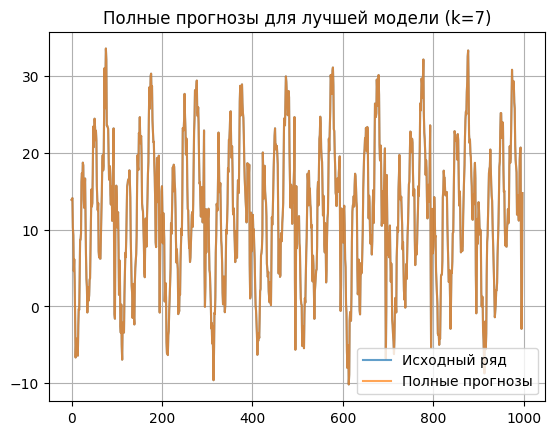

In [20]:
plt.plot(y_original, label='Исходный ряд', alpha=0.7)
plt.plot(full_predictions_original, label='Полные прогнозы', alpha=0.7)
plt.title(f'Полные прогнозы для лучшей модели (k={best_k})')
plt.legend()
plt.grid(True)

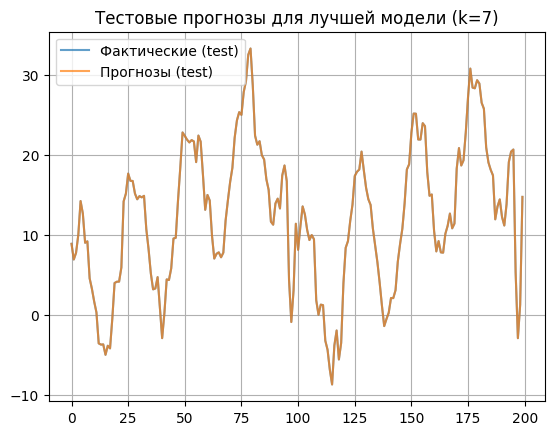

In [21]:
test_start = int(0.8 * len(X_full))
plt.plot(y_original[test_start:], label='Фактические (test)', alpha=0.7)
plt.plot(full_predictions_original[test_start:], label='Прогнозы (test)', alpha=0.7)
plt.title(f'Тестовые прогнозы для лучшей модели (k={best_k})')
plt.legend()
plt.grid(True)

<p class="task" id="2"></p>

2\. Загрузите файл `PV_Elec_Gas2.csv`. Опишите класс `ElectricityDataset`, который разбивает данные на окна в соответствии со следующей схемой:

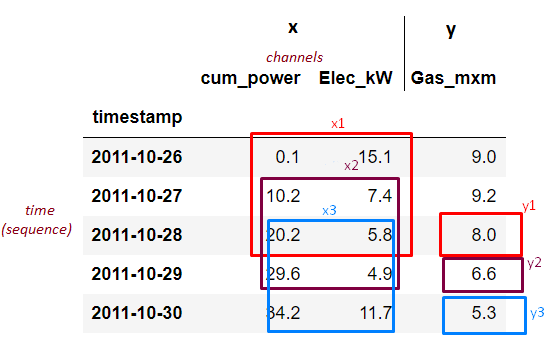

Разбейте набор данных на обучающую и тестовую выборку. Для теста оставьте данные за 2019 год.

- [ ] Проверено на семинаре

In [22]:
class ElectricityDataset(Dataset):
    """Оконный Dataset для многомерного временного ряда.

    Для train scaler'ы обучаются только на train-годах. Для test нужно передать
    feature_scaler и target_scaler от train Dataset, чтобы исключить data leakage.
    """
    def __init__(self, data, window_size, target_col='cum_power', feature_cols=None,
                 scale=True, train=True, test_year=None,
                 feature_scaler=None, target_scaler=None):
        self.window_size = int(window_size)
        self.target_col = target_col
        self.feature_cols = list(feature_cols) if feature_cols is not None else [target_col]
        self.scale = bool(scale)
        self.train = bool(train)

        frame = data.copy()
        if 'Unnamed: 0' in frame.columns and 'timestamp' not in frame.columns:
            frame = frame.rename(columns={'Unnamed: 0': 'timestamp'})
        if 'timestamp' not in frame.columns:
            raise KeyError("В данных должен быть столбец 'timestamp' или 'Unnamed: 0'")

        required = ['timestamp', self.target_col] + self.feature_cols
        missing = [c for c in required if c not in frame.columns]
        if missing:
            raise KeyError(f'В таблице отсутствуют столбцы: {missing}')

        frame['timestamp'] = pd.to_datetime(frame['timestamp'])
        frame = frame.sort_values('timestamp').dropna(subset=required).reset_index(drop=True)
        frame['year'] = frame['timestamp'].dt.year
        frame['month'] = frame['timestamp'].dt.month

        available_years = sorted(frame['year'].unique())
        if not available_years:
            raise ValueError('После очистки данных не осталось наблюдений')
        if test_year is None:
            test_year = available_years[-1]
        self.test_year = int(test_year)

        train_frame = frame[frame['year'] != self.test_year].copy()
        test_frame = frame[frame['year'] == self.test_year].copy()
        if train_frame.empty or test_frame.empty:
            raise ValueError(
                f'Для разбиения по году нужны и train, и test. Доступные годы: {available_years}, '
                f'test_year={self.test_year}'
            )

        selected = train_frame if self.train else test_frame
        self.data = selected.reset_index(drop=True)

        # Fit только на train, transform train/test одними и теми же параметрами.
        self.feature_scaler = feature_scaler
        self.target_scaler = target_scaler
        if self.scale:
            if self.feature_scaler is None:
                if not self.train:
                    raise ValueError('Для test передайте feature_scaler, обученный на train')
                self.feature_scaler = StandardScaler().fit(train_frame[self.feature_cols])
            if self.target_scaler is None:
                if not self.train:
                    raise ValueError('Для test передайте target_scaler, обученный на train')
                self.target_scaler = StandardScaler().fit(train_frame[[self.target_col]])

            feature_values = self.feature_scaler.transform(self.data[self.feature_cols]).astype(np.float32)
            target_values = self.target_scaler.transform(self.data[[self.target_col]]).reshape(-1).astype(np.float32)
        else:
            feature_values = self.data[self.feature_cols].to_numpy(dtype=np.float32)
            target_values = self.data[self.target_col].to_numpy(dtype=np.float32)

        self.sequences = []
        self.target_timestamps = []
        for i in range(self.window_size, len(self.data)):
            window = feature_values[i-self.window_size:i]
            target = target_values[i]
            self.sequences.append((window, target))
            self.target_timestamps.append(self.data.loc[i, 'timestamp'])

        split_name = 'train' if self.train else 'test'
        print(
            f'{split_name}: {len(self.sequences)} окон, years=' 
            f'{sorted(self.data["year"].unique().tolist())}, '
            f'features={self.feature_cols}, target={self.target_col}'
        )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        features, target = self.sequences[idx]
        return torch.tensor(features, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

    def get_feature_names(self):
        return self.feature_cols

    def inverse_transform_target(self, values):
        values = np.asarray(values).reshape(-1, 1)
        if self.scale and self.target_scaler is not None:
            return self.target_scaler.inverse_transform(values).reshape(-1)
        return values.reshape(-1)

In [23]:
data = pd.read_csv("PV_Elec_Gas2.csv"); data.head(), data.info(), data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2948 entries, 0 to 2947
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2948 non-null   object 
 1   cum_power   2948 non-null   float64
 2   Elec_kW     2948 non-null   float64
 3   Gas_mxm     2948 non-null   float64
dtypes: float64(3), object(1)
memory usage: 92.3+ KB


(   Unnamed: 0  cum_power  Elec_kW  Gas_mxm
 0  2011-10-26        0.1     15.1      9.0
 1  2011-10-27       10.2      7.4      9.2
 2  2011-10-28       20.2      5.8      8.0
 3  2011-10-29       29.6      4.9      6.6
 4  2011-10-30       34.2     11.7      5.3,
 None,
           cum_power      Elec_kW      Gas_mxm
 count   2948.000000  2948.000000  2948.000000
 mean   15630.977510     4.520014     8.434735
 std     9408.564934     9.838686     6.410362
 min        0.100000   -24.000000     0.000000
 25%     7842.500000    -3.000000     2.000000
 50%    15996.500000     6.000000     8.000000
 75%    23996.500000    13.000000    14.000000
 max    32244.000000    34.000000    29.000000)

In [24]:
if 'Unnamed: 0' in data.columns:
    data = data.rename(columns={'Unnamed: 0': 'timestamp'})

In [25]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['year'] = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month

print(f"\nДоступные годы в данных: {sorted(data['year'].unique())}")
print(f"Диапазон дат: от {data['timestamp'].min()} до {data['timestamp'].max()}")


Доступные годы в данных: [np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019)]
Диапазон дат: от 2011-10-26 00:00:00 до 2019-11-20 00:00:00


In [26]:
target_col = 'cum_power'
feature_columns = ['cum_power', 'Elec_kW', 'Gas_mxm']
available_years = sorted(data['year'].unique())
test_year = available_years[-1]

In [27]:
window_size = 7
train_dataset = ElectricityDataset(
    data=data,
    window_size=window_size,
    target_col=target_col,
    feature_cols=feature_columns,
    scale=True,
    train=True,
    test_year=test_year,
)

test_dataset = ElectricityDataset(
    data=data,
    window_size=window_size,
    target_col=target_col,
    feature_cols=feature_columns,
    scale=True,
    train=False,
    test_year=test_year,
    feature_scaler=train_dataset.feature_scaler,
    target_scaler=train_dataset.target_scaler,
)

train: 2617 окон, years=[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018], features=['cum_power', 'Elec_kW', 'Gas_mxm'], target=cum_power
test: 317 окон, years=[2019], features=['cum_power', 'Elec_kW', 'Gas_mxm'], target=cum_power


In [28]:
if len(train_dataset) > 0:
    features, target = train_dataset[0]
    print(f"\nПервый пример из обучающей выборки:")
    print(f"Размер окна фичей: {features.shape}")  # (window_size, num_features)
    print(f"Целевое значение: {target.item():.4f}")

    # Показываем значения фичей в окне
    feature_names = train_dataset.get_feature_names()
    print(f"Фичи в окне (последний временной шаг):")
    for i, name in enumerate(feature_names):
        print(f"  {name}: {features[-1, i]:.4f}")


Первый пример из обучающей выборки:
Размер окна фичей: torch.Size([7, 3])
Целевое значение: -1.6501
Фичи в окне (последний временной шаг):
  cum_power: -1.6507
  Elec_kW: -0.1142
  Gas_mxm: -0.5073


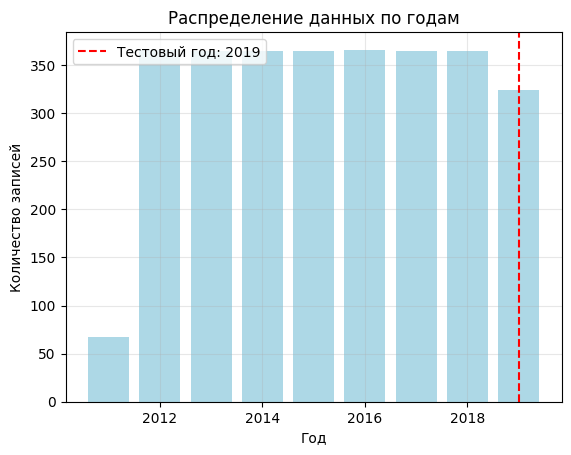

In [29]:
year_counts = data['year'].value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color='lightblue')
plt.axvline(x=test_year, color='red', linestyle='--', label=f'Тестовый год: {test_year}')
plt.title('Распределение данных по годам')
plt.xlabel('Год')
plt.ylabel('Количество записей')
plt.legend()
plt.grid(True, alpha=0.3)

(array([14975., 15340., 15706., 16071., 16436., 16801., 17167., 17532.,
        17897., 18262.]),
 [Text(14975.0, 0, '2011'),
  Text(15340.0, 0, '2012'),
  Text(15706.0, 0, '2013'),
  Text(16071.0, 0, '2014'),
  Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018'),
  Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020')])

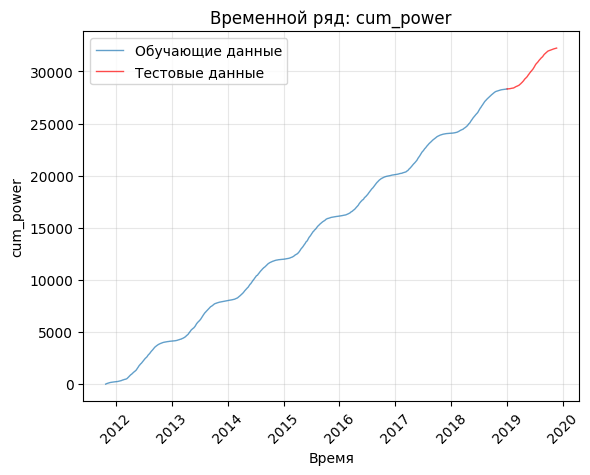

In [30]:
train_data = data[data['year'] != test_year]
plt.plot(train_data['timestamp'], train_data[target_col],
          label='Обучающие данные', alpha=0.7, linewidth=1)
test_data = data[data['year'] == test_year]
if not test_data.empty:
    plt.plot(test_data['timestamp'], test_data[target_col],
              label='Тестовые данные', alpha=0.7, linewidth=1, color='red')

plt.title(f'Временной ряд: {target_col}')
plt.xlabel('Время')
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

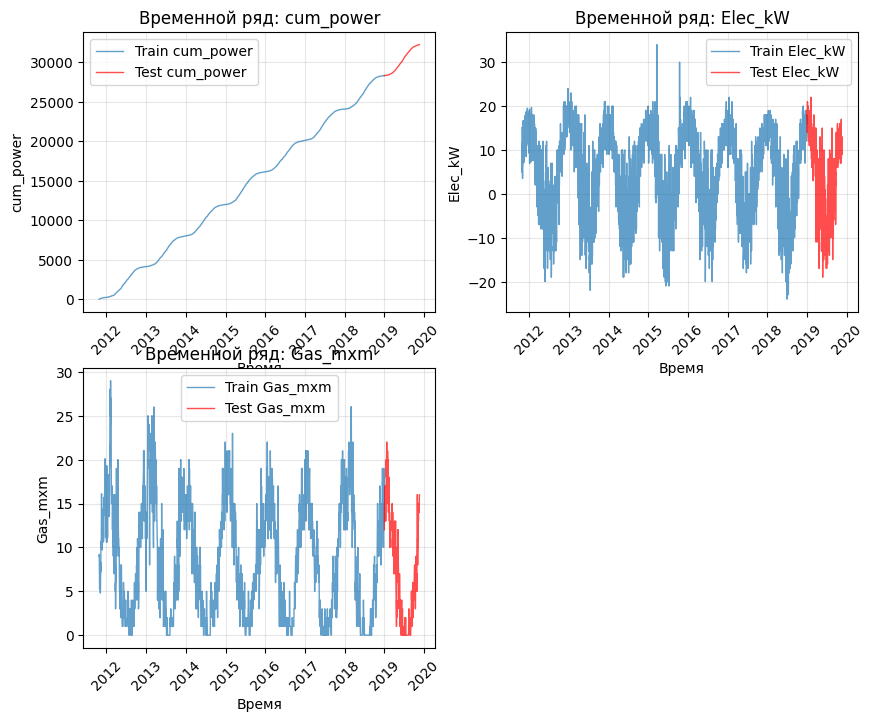

In [31]:
plt.figure(figsize=(10, 8))

numeric_cols = ['cum_power', 'Elec_kW', 'Gas_mxm']
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)

    train_col = train_data[col] if len(train_data) > 0 else []
    test_col = test_data[col] if len(test_data) > 0 else []

    if len(train_col) > 0:
        plt.plot(train_data['timestamp'], train_col,
                label=f'Train {col}', alpha=0.7, linewidth=1)
    if len(test_col) > 0:
        plt.plot(test_data['timestamp'], test_col,
                label=f'Test {col}', alpha=0.7, linewidth=1, color='red')

    plt.title(f'Временной ряд: {col}')
    plt.xlabel('Время')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

<p class="task" id="3"></p>

3\. Решите задачу предсказания столбца `Gas_mxm` на основе столбцов `cum_power` и `Elec_kW` с использованием одномерных сверток. Для оптимизации используйте мини-пакетный градиентный спуск с использованием `DataLoader`. Обратите внимание, что при создании `DataLoader` вы не можете перемешивать данные.

Постройте график изменения значения функции потерь на обучающем и тестовом множестве в зависимости от номера эпохи. Визуализируйте на одном графике прогнозы модели и предсказываемый временной ряд.

- [ ] Проверено на семинаре

In [32]:
class GasForecastCNN(nn.Module):
    """1D-CNN: окно (cum_power, Elec_kW) -> Gas_mxm следующего момента."""
    def __init__(self, in_channels=2, hidden_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.regressor = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        # Dataset: (batch, window, features) -> Conv1d: (batch, features, window)
        x = x.permute(0, 2, 1)
        x = self.net(x).squeeze(-1)
        return self.regressor(x).squeeze(-1)

In [33]:
def evaluate_regression_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_items = 0
    with torch.no_grad():
        for features, target in loader:
            features = features.to(device)
            target = target.to(device)
            pred = model(features)
            loss = criterion(pred, target)
            batch_size = features.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size
    return total_loss / max(total_items, 1)


def train_gas_model(model, train_loader, test_loader, epochs=50, lr=1e-3, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_history, test_history = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_items = 0
        for features, target in train_loader:
            features = features.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            pred = model(features)
            loss = criterion(pred, target)
            loss.backward()
            optimizer.step()

            batch_size = features.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size

        train_loss = total_loss / max(total_items, 1)
        test_loss = evaluate_regression_loss(model, test_loader, criterion, device)
        train_history.append(train_loss)
        test_history.append(test_loss)

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f'Epoch {epoch:02d}/{epochs}: train MSE={train_loss:.6f}, test MSE={test_loss:.6f}')

    return model, train_history, test_history, device

train: 2617 окон, years=[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018], features=['cum_power', 'Elec_kW'], target=Gas_mxm
test: 317 окон, years=[2019], features=['cum_power', 'Elec_kW'], target=Gas_mxm
Первое окно: (7, 2) target shape: ()
Фичи: ['cum_power', 'Elec_kW'] Цель: Gas_mxm
DataLoader shuffle=False; batch_size= 64
Epoch 01/50: train MSE=0.823365, test MSE=0.503161
Epoch 05/50: train MSE=0.309307, test MSE=0.256401
Epoch 10/50: train MSE=0.297274, test MSE=0.268876
Epoch 15/50: train MSE=0.292747, test MSE=0.276101
Epoch 20/50: train MSE=0.290537, test MSE=0.276744
Epoch 25/50: train MSE=0.288719, test MSE=0.275349
Epoch 30/50: train MSE=0.287181, test MSE=0.272762
Epoch 35/50: train MSE=0.285752, test MSE=0.269515
Epoch 40/50: train MSE=0.284361, test MSE=0.269375
Epoch 45/50: train MSE=0.282783, test MSE=0.269709
Epoch 50/50: train MSE=0.281408, test MSE=0.270568


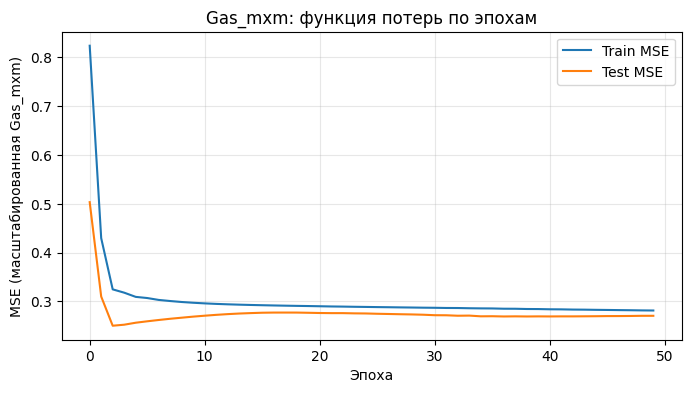

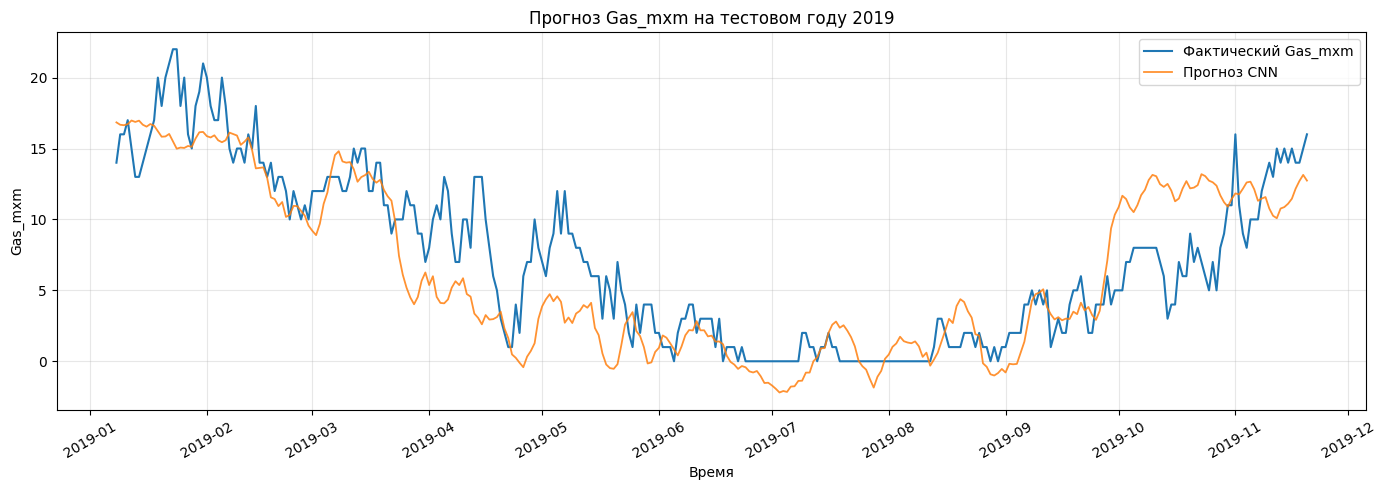

Итоговый train MSE: 0.281408
Итоговый test MSE:  0.270568


In [34]:
# Gas_mxm <- предыдущие значения cum_power и Elec_kW.
GAS_TARGET = 'Gas_mxm'
GAS_FEATURES = ['cum_power', 'Elec_kW']
GAS_WINDOW = 7
BATCH_SIZE = 64
EPOCHS = 50

available_years = sorted(data['year'].unique())
test_year = available_years[-1]

gas_train_dataset = ElectricityDataset(
    data=data,
    window_size=GAS_WINDOW,
    target_col=GAS_TARGET,
    feature_cols=GAS_FEATURES,
    scale=True,
    train=True,
    test_year=test_year,
)
gas_test_dataset = ElectricityDataset(
    data=data,
    window_size=GAS_WINDOW,
    target_col=GAS_TARGET,
    feature_cols=GAS_FEATURES,
    scale=True,
    train=False,
    test_year=test_year,
    feature_scaler=gas_train_dataset.feature_scaler,
    target_scaler=gas_train_dataset.target_scaler,
)

# Для временных рядов shuffle=False обязателен по условию.
gas_train_loader = DataLoader(gas_train_dataset, batch_size=BATCH_SIZE, shuffle=False)
gas_test_loader = DataLoader(gas_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

first_x, first_y = gas_train_dataset[0]
print('Первое окно:', tuple(first_x.shape), 'target shape:', tuple(first_y.shape))
print('Фичи:', GAS_FEATURES, 'Цель:', GAS_TARGET)
print('DataLoader shuffle=False; batch_size=', BATCH_SIZE)

gas_model = GasForecastCNN(in_channels=len(GAS_FEATURES), hidden_channels=32)
gas_model, gas_train_losses, gas_test_losses, gas_device = train_gas_model(
    gas_model, gas_train_loader, gas_test_loader, epochs=EPOCHS, lr=1e-3
)

# Loss по эпохам.
plt.figure(figsize=(8, 4))
plt.plot(gas_train_losses, label='Train MSE')
plt.plot(gas_test_losses, label='Test MSE')
plt.xlabel('Эпоха')
plt.ylabel('MSE (масштабированная Gas_mxm)')
plt.title('Gas_mxm: функция потерь по эпохам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Предсказания на test и возврат в исходный масштаб.
gas_model.eval()
pred_scaled, true_scaled = [], []
with torch.no_grad():
    for features, target in gas_test_loader:
        pred = gas_model(features.to(gas_device)).cpu().numpy()
        pred_scaled.extend(pred.tolist())
        true_scaled.extend(target.numpy().tolist())

pred_gas = gas_test_dataset.inverse_transform_target(np.array(pred_scaled))
true_gas = gas_test_dataset.inverse_transform_target(np.array(true_scaled))
time_axis = pd.to_datetime(gas_test_dataset.target_timestamps)

plt.figure(figsize=(14, 5))
plt.plot(time_axis, true_gas, label='Фактический Gas_mxm', linewidth=1.5)
plt.plot(time_axis, pred_gas, label='Прогноз CNN', linewidth=1.3, alpha=0.85)
plt.xlabel('Время')
plt.ylabel('Gas_mxm')
plt.title(f'Прогноз Gas_mxm на тестовом году {test_year}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'Итоговый train MSE: {gas_train_losses[-1]:.6f}')
print(f'Итоговый test MSE:  {gas_test_losses[-1]:.6f}')

<p class="task" id="4"></p>

4\. Считайте файлы `polarity/positive_reviews.txt` (положительные обзоры на фильмы) и `polarity/negative_reviews.txt` (отрицательные обозоры на фильмы) и разбейте на обучающую и тестовую выборку. Выполните предобработку текста и создайте Vocab на основе обучающей выборки (токен - слово). Выведите на экран количество токенов в полученном словаре.

Создайте класс `PolarityDataset` и реализуйте метод `__getitem__` таким образом, чтобы он возвращал набор индексов токенов (слов) для текста и метки классов для этих текстов. Создайте два объекта класса `PolarityDataset` для обучающей и тестовой выборки. Выведите на экраны количество элементов и распределение данных по классам в каждом из них.

- [ ] Проверено на семинаре

In [35]:
class PolarityDataset(Dataset):
    """Dataset индексов токенов и меток sentiment."""
    def __init__(self, texts, labels, vocab, max_length=None):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.text_indices = [vocab.text_to_indices(text) for text in self.texts]

        inferred_max = max((len(x) for x in self.text_indices), default=1)
        self.max_length = int(max_length if max_length is not None else inferred_max)

        self.padded_indices = []
        for indices in self.text_indices:
            clipped = indices[:self.max_length]
            padded = clipped + [0] * (self.max_length - len(clipped))
            self.padded_indices.append(padded)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        indices = torch.tensor(self.padded_indices[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        length = torch.tensor(min(len(self.text_indices[idx]), self.max_length), dtype=torch.long)
        return indices, label, length

    def get_class_distribution(self):
        return Counter(self.labels)

    def get_sequence_stats(self):
        lengths = [len(x) for x in self.text_indices]
        return {
            'min_length': min(lengths),
            'max_length': max(lengths),
            'mean_length': float(np.mean(lengths)),
            'median_length': float(np.median(lengths)),
        }

In [36]:
def read_reviews(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        reviews = f.readlines()
    return [review.strip() for review in reviews if review.strip()]

In [37]:
def resolve_review_file(filename):
    candidates = [
        os.path.join('polarity', filename),
        filename,
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f'Не найден {filename}. Проверены пути: {candidates}')

positive_path = resolve_review_file('positive_reviews.txt')
negative_path = resolve_review_file('negative_reviews.txt')
positive_reviews = read_reviews(positive_path)
negative_reviews = read_reviews(negative_path)
print('Positive:', positive_path, len(positive_reviews))
print('Negative:', negative_path, len(negative_reviews))

Positive: positive_reviews.txt 5331
Negative: negative_reviews.txt 5331


In [38]:
texts = positive_reviews + negative_reviews
labels = [1] * len(positive_reviews) + [0] * len(negative_reviews); len(texts)

10662

In [39]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

In [40]:
def preprocess_text(text):
    """Предобработка текста: приведение к нижнему регистру и токенизация"""
    text = text.lower()
    words = re.findall(r'\b[a-zA-Zа-яА-Я]+\b', text)
    return words

In [41]:
class Vocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = {}
        self.word_counts = Counter()

    def build_vocab(self, texts):
        # статистика по словам
        for text in texts:
            words = preprocess_text(text)
            self.word_counts.update(words)

        self.word2idx = {'<PAD>': 0, '<UNK>': 1}  # PAD для padding, UNK для неизвестных слов

        idx = 2
        for word, count in self.word_counts.items():
            if count >= self.min_freq:
                self.word2idx[word] = idx
                idx += 1

        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def __len__(self):
        return len(self.word2idx)

    def __getitem__(self, word):
        """Возвращает индекс слова или индекс UNK токена"""
        return self.word2idx.get(word, self.word2idx['<UNK>'])

    def text_to_indices(self, text):
        """Преобразует текст в список индексов"""
        words = preprocess_text(text)
        return [self[word] for word in words]

In [42]:
vocab = Vocab(min_freq=2)
vocab.build_vocab(train_texts); len(vocab), list(vocab.word2idx.items())[:10]

(8720,
 [('<PAD>', 0),
  ('<UNK>', 1),
  ('it', 2),
  ('s', 3),
  ('a', 4),
  ('tour', 5),
  ('de', 6),
  ('force', 7),
  ('written', 8),
  ('and', 9)])

In [43]:
print('PolarityDataset готов:', issubclass(PolarityDataset, Dataset))

PolarityDataset готов: True


In [44]:
train_dataset = PolarityDataset(train_texts, train_labels, vocab)
test_dataset = PolarityDataset(test_texts, test_labels, vocab,
                              max_length=train_dataset.max_length)

In [45]:
print(f"\nОБУЧАЮЩАЯ ВЫБОРКА:")
print(f"Количество элементов: {len(train_dataset)}")
print(f"Распределение по классам: {train_dataset.get_class_distribution()}")
print(f"0 - отрицательные, 1 - положительные")
stats = train_dataset.get_sequence_stats()
print(f"Статистика длин последовательностей:")
print(f"  Минимальная: {stats['min_length']}")
print(f"  Максимальная: {stats['max_length']}")
print(f"  Средняя: {stats['mean_length']:.2f}")
print(f"  Медианная: {stats['median_length']}")

print(f"\nТЕСТОВАЯ ВЫБОРКА:")
print(f"Количество элементов: {len(test_dataset)}")
print(f"Распределение по классам: {test_dataset.get_class_distribution()}")
print(f"0 - отрицательные, 1 - положительные")
stats = test_dataset.get_sequence_stats()
print(f"Статистика длин последовательностей:")
print(f"  Минимальная: {stats['min_length']}")
print(f"  Максимальная: {stats['max_length']}")
print(f"  Средняя: {stats['mean_length']:.2f}")
print(f"  Медианная: {stats['median_length']}")


ОБУЧАЮЩАЯ ВЫБОРКА:
Количество элементов: 8529
Распределение по классам: Counter({1: 4265, 0: 4264})
0 - отрицательные, 1 - положительные
Статистика длин последовательностей:
  Минимальная: 1
  Максимальная: 53
  Средняя: 19.33
  Медианная: 19.0

ТЕСТОВАЯ ВЫБОРКА:
Количество элементов: 2133
Распределение по классам: Counter({0: 1067, 1: 1066})
0 - отрицательные, 1 - положительные
Статистика длин последовательностей:
  Минимальная: 1
  Максимальная: 45
  Средняя: 19.17
  Медианная: 19.0


In [46]:
print(f"Размер словаря: {len(vocab)}")
print(f"Количество уникальных слов в обучающей выборке: {len(vocab.word_counts)}")
print(f"Порог частоты для включения в словарь: {vocab.min_freq}")

Размер словаря: 8720
Количество уникальных слов в обучающей выборке: 16348
Порог частоты для включения в словарь: 2


In [47]:
print(f"\n10 самых частых слов:")
for word, count in vocab.word_counts.most_common(10):
    print(f"  '{word}': {count} раз")


10 самых частых слов:
  'the': 8222 раз
  'a': 5928 раз
  'and': 5007 раз
  'of': 4952 раз
  'to': 3444 раз
  's': 2875 раз
  'is': 2725 раз
  'it': 2708 раз
  'in': 2135 раз
  'that': 2124 раз


In [48]:
rare_words = sum(1 for count in vocab.word_counts.values() if count < vocab.min_freq)
print(f"Слов исключено из-за низкой частоты: {rare_words}")

Слов исключено из-за низкой частоты: 7630


In [49]:
train_lengths = [len(indices) for indices in train_dataset.text_indices]
test_lengths = [len(indices) for indices in test_dataset.text_indices]

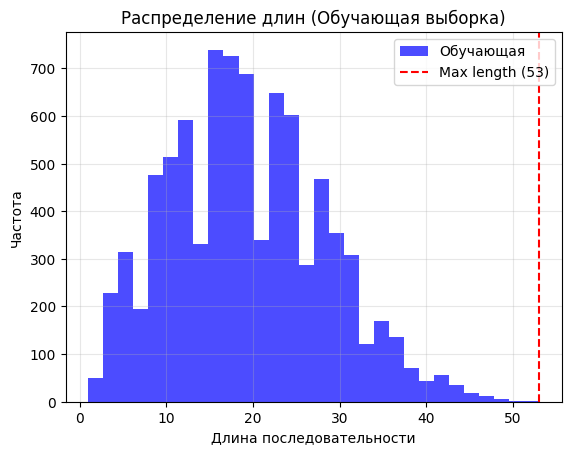

In [50]:
plt.hist(train_lengths, bins=30, alpha=0.7, color='blue', label='Обучающая')
plt.axvline(train_dataset.max_length, color='red', linestyle='--', label=f'Max length ({train_dataset.max_length})')
plt.xlabel('Длина последовательности')
plt.ylabel('Частота')
plt.title('Распределение длин (Обучающая выборка)')
plt.legend()
plt.grid(True, alpha=0.3)

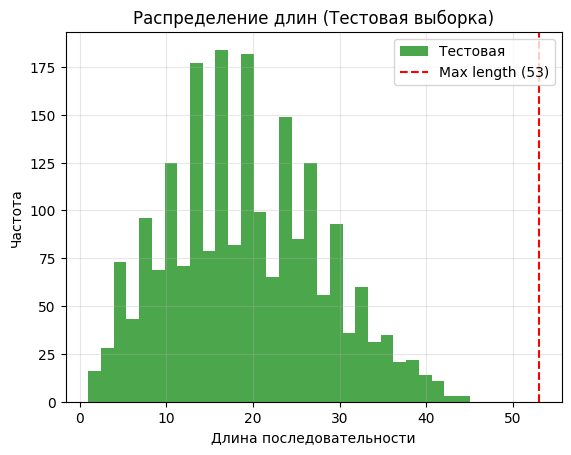

In [51]:
plt.hist(test_lengths, bins=30, alpha=0.7, color='green', label='Тестовая')
plt.axvline(test_dataset.max_length, color='red', linestyle='--', label=f'Max length ({test_dataset.max_length})')
plt.xlabel('Длина последовательности')
plt.ylabel('Частота')
plt.title('Распределение длин (Тестовая выборка)')
plt.legend()
plt.grid(True, alpha=0.3)

<p class="task" id="5"></p>

5\. Решите задачу классификации текстов обзоров с использованием одномерных сверток. Для преобразования последовательности индексов в последовательность векторов используйте слой `nn.Embedding`. Обратите внимание, что `nn.Conv1d` ожидает на вход трехмерный тензор размерности `(batch, embedding_dim, seq_len)`. Выведите на экран отчет по классификации для обучающей и тестовой выборки после завершения процесса обучения. Добейтесь accuracy на тестовой выборке не менее 70%.

- [ ] Проверено на семинаре

In [52]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes, num_classes, dropout=0.5):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Несколько сверточных слоев с разными размерами фильтров
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)
        embedded = embedded.permute(0, 2, 1) # Permute для Conv1d: (batch_size, embedding_dim, seq_len)
        conv_outputs = []
        for conv in self.convs:
            # conv output: (batch_size, num_filters, seq_len - kernel_size + 1)
            conv_out = conv(embedded)
            #  ReLU и max pooling по времени
            conv_out = torch.relu(conv_out)
            conv_out = torch.max_pool1d(conv_out, conv_out.size(2))
            # output: (batch_size, num_filters, 1)
            conv_out = conv_out.squeeze(2)
            conv_outputs.append(conv_out)

        concatenated = torch.cat(conv_outputs, 1)
        # output: (batch_size, num_filters * len(filter_sizes))
        concatenated = self.dropout(concatenated)
        output = self.fc(concatenated)
        return output

In [53]:
def classification_accuracy(model, data_loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for data, target, lengths in data_loader:
            output = model(data)
            preds.extend(output.argmax(dim=1).cpu().numpy())
            targets.extend(target.cpu().numpy())
    return accuracy_score(targets, preds)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=20, patience=4):
    """Обучение с model selection только по validation, без использования test."""
    train_losses, val_accuracies = [], []
    best_val = -1.0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss = 0.0
        total_items = 0
        for data, target, lengths in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            batch_size = data.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size

        avg_loss = total_loss / max(total_items, 1)
        val_accuracy = classification_accuracy(model, val_loader)
        train_losses.append(avg_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch:02d}/{num_epochs}: loss={avg_loss:.4f}, val_accuracy={val_accuracy:.4f}')

        if val_accuracy > best_val + 1e-4:
            best_val = val_accuracy
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f'Early stopping по validation после {epoch} эпох; best val={best_val:.4f}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return train_losses, val_accuracies, best_val

In [54]:
def evaluate_model(model, data_loader, dataset_name="", class_names=['Negative', 'Positive']):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target, lengths in data_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)

    print(f"\n{'='*60}")
    print(f"ОТЧЕТ ПО КЛАССИФИКАЦИИ - {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return accuracy, all_preds, all_targets

In [55]:
def main():
    EMBEDDING_DIM = 100
    NUM_FILTERS = 100
    FILTER_SIZES = [2, 3, 4]
    NUM_CLASSES = 2
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 20
    DROPOUT = 0.5

    print('Параметры модели:')
    print(f'Embedding dim: {EMBEDDING_DIM}')
    print(f'Number of filters: {NUM_FILTERS}')
    print(f'Filter sizes: {FILTER_SIZES}')
    print(f'Batch size: {BATCH_SIZE}')
    print(f'Learning rate: {LEARNING_RATE}')

    # Внутри исходной train-выборки выделяем validation. Test не участвует в обучении.
    all_train_idx = np.arange(len(train_dataset))
    opt_idx, val_idx = train_test_split(
        all_train_idx,
        test_size=0.15,
        random_state=SEED,
        stratify=np.asarray(train_labels),
    )
    opt_dataset = Subset(train_dataset, opt_idx.tolist())
    val_dataset = Subset(train_dataset, val_idx.tolist())

    train_loader = DataLoader(opt_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = TextCNN(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        num_filters=NUM_FILTERS,
        filter_sizes=FILTER_SIZES,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    )
    print(f'\nРазмер словаря: {len(vocab)}')
    print(f'Оптимизация: {len(opt_dataset)}, validation: {len(val_dataset)}, test: {len(test_dataset)}')
    print(f'Общее количество параметров: {sum(p.numel() for p in model.parameters()):,}')

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_losses, val_accuracies, best_val = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=NUM_EPOCHS, patience=4,
    )

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses)+1), train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(val_accuracies)+1), val_accuracies)
    plt.axhline(0.70, linestyle='--', label='70% target')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Отчёты после завершения обучения. Test используется только здесь.
    train_accuracy, _, _ = evaluate_model(model, train_loader, 'ОБУЧАЮЩАЯ ВЫБОРКА')
    test_accuracy, _, _ = evaluate_model(model, test_loader, 'ТЕСТОВАЯ ВЫБОРКА')

    print(f'\nBest validation accuracy: {best_val:.4f}')
    print(f'Accuracy на обучающей выборке: {train_accuracy:.4f}')
    print(f'Accuracy на тестовой выборке:  {test_accuracy:.4f}')
    if test_accuracy >= 0.70:
        print('ЦЕЛЕВАЯ ТОЧНОСТЬ >= 70% ДОСТИГНУТА')
    else:
        print('Целевая точность 70% пока не достигнута; увеличьте число эпох/фильтров.')

    return model, train_accuracy, test_accuracy

In [56]:
def test_single_examples(model, vocab, texts, true_labels=None):
    model.eval()
    class_names = ['Negative', 'Positive']
    for i, text in enumerate(texts):
        words = preprocess_text(text)
        indices = [vocab[word] for word in words]
        # Паддинг до максимальной длины
        if len(indices) < train_dataset.max_length:
            padded = indices + [0] * (train_dataset.max_length - len(indices))
        else:
            padded = indices[:train_dataset.max_length]
        input_tensor = torch.tensor([padded], dtype=torch.long)
        # Предсказание
        with torch.no_grad():
            output = model(input_tensor)
            prediction = output.argmax(dim=1).item()
            probabilities = torch.softmax(output, dim=1)

        print(f"\nПример {i+1}:")
        print(f"Текст: {text[:100]}...")
        print(f"Предсказание: {class_names[prediction]}")
        print(f"Вероятности: Negative: {probabilities[0][0]:.4f}, Positive: {probabilities[0][1]:.4f}")
        if true_labels is not None:
            print(f"Истинный класс: {class_names[true_labels[i]]}")

        if true_labels is not None and prediction != true_labels[i]:
            print("ОШИБКА КЛАССИФИКАЦИИ")
        else:
            print("Правильная классификация")

Параметры модели:
Embedding dim: 100
Number of filters: 100
Filter sizes: [2, 3, 4]
Batch size: 32
Learning rate: 0.001

Размер словаря: 8720
Оптимизация: 7249, validation: 1280, test: 2133
Общее количество параметров: 962,902
Epoch 01/20: loss=0.7276, val_accuracy=0.6469
Epoch 02/20: loss=0.6198, val_accuracy=0.6852
Epoch 03/20: loss=0.5440, val_accuracy=0.7063
Epoch 04/20: loss=0.4615, val_accuracy=0.7148
Epoch 05/20: loss=0.3930, val_accuracy=0.7039
Epoch 06/20: loss=0.3156, val_accuracy=0.7195
Epoch 07/20: loss=0.2556, val_accuracy=0.7227
Epoch 08/20: loss=0.2095, val_accuracy=0.7422
Epoch 09/20: loss=0.1592, val_accuracy=0.7352
Epoch 10/20: loss=0.1265, val_accuracy=0.7516
Epoch 11/20: loss=0.1076, val_accuracy=0.7438
Epoch 12/20: loss=0.0950, val_accuracy=0.7422
Epoch 13/20: loss=0.0657, val_accuracy=0.7375
Epoch 14/20: loss=0.0601, val_accuracy=0.7477
Early stopping по validation после 14 эпох; best val=0.7516


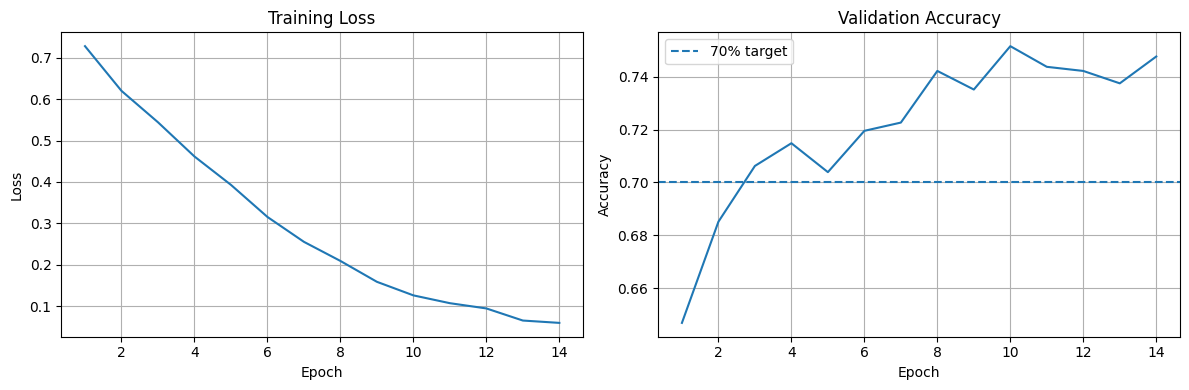


ОТЧЕТ ПО КЛАССИФИКАЦИИ - ОБУЧАЮЩАЯ ВЫБОРКА
Accuracy: 0.9966

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      3624
    Positive       1.00      1.00      1.00      3625

    accuracy                           1.00      7249
   macro avg       1.00      1.00      1.00      7249
weighted avg       1.00      1.00      1.00      7249



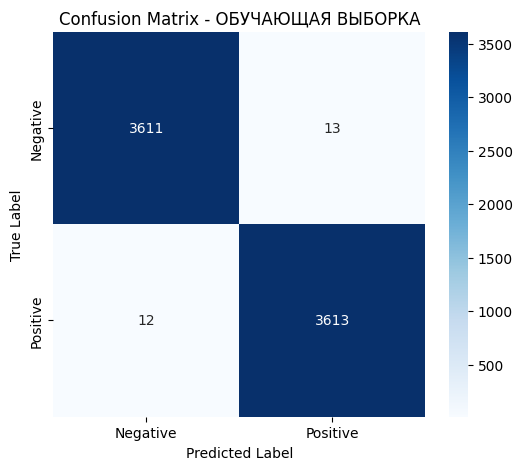


ОТЧЕТ ПО КЛАССИФИКАЦИИ - ТЕСТОВАЯ ВЫБОРКА
Accuracy: 0.7332

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73      1067
    Positive       0.73      0.73      0.73      1066

    accuracy                           0.73      2133
   macro avg       0.73      0.73      0.73      2133
weighted avg       0.73      0.73      0.73      2133



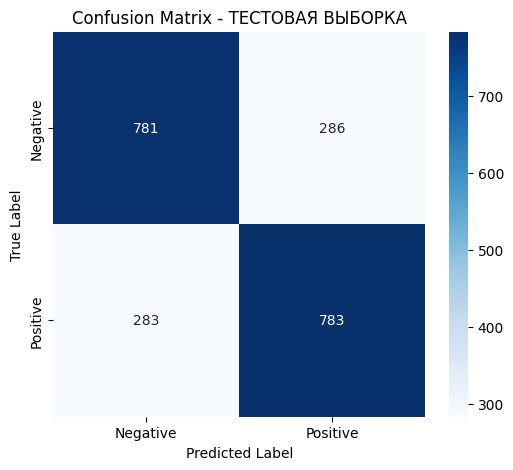


Best validation accuracy: 0.7516
Accuracy на обучающей выборке: 0.9966
Accuracy на тестовой выборке:  0.7332
ЦЕЛЕВАЯ ТОЧНОСТЬ >= 70% ДОСТИГНУТА

Пример 1:
Текст: [t]here's only so much anyone can do with a florid , overplotted , anne rice rock 'n' roll vampire n...
Предсказание: Negative
Вероятности: Negative: 0.9781, Positive: 0.0219
Истинный класс: Negative
Правильная классификация

Пример 2:
Текст: too many scenarios in which the hero might have an opportunity to triumphantly sermonize , and too f...
Предсказание: Negative
Вероятности: Negative: 0.9901, Positive: 0.0099
Истинный класс: Negative
Правильная классификация

Пример 3:
Текст: while surprisingly sincere , this average little story is adorned with some awesome action photograp...
Предсказание: Positive
Вероятности: Negative: 0.0781, Positive: 0.9219
Истинный класс: Positive
Правильная классификация

Пример 4:
Текст: perfectly enjoyable , instantly forgettable , nothing to write home about ....
Предсказание: Positive
Вероят

In [57]:
trained_model, train_acc, test_acc = main()
test_examples = test_texts[:5]
test_example_labels = test_labels[:5]
test_single_examples(trained_model, vocab, test_examples, test_example_labels)

print(f"\n{'='*60}")
print('ДИАГНОСТИКА ЭМБЕДДИНГОВ')
print(f"{'='*60}")
embedding_weights = trained_model.embedding.weight.data
print(f'Размерность матрицы эмбеддингов: {embedding_weights.shape}')
embedding_norms = torch.norm(embedding_weights, dim=1)
top_indices = torch.topk(embedding_norms, k=min(10, len(embedding_norms))).indices
print('\nСлова с наибольшей нормой embedding-вектора (это НЕ мера важности для классификации):')
for idx in top_indices:
    idx_int = idx.item()
    if idx_int in vocab.idx2word:
        print(f"  '{vocab.idx2word[idx_int]}': {embedding_norms[idx].item():.4f}")

<p class="task" id="6"></p>

6\. Придумайте небольшой отзыв, прогоните его через модель и выведите метку предсказанного класса (позитивный или негативный). Сделайте это для явно позитивного и явно негативного отзыва.

- [ ] Проверено на семинаре

In [58]:
def analyze_embedding_norms(model, vocab, top_k=10):
    """Диагностика норм embedding-векторов; не интерпретируется как feature importance."""
    embedding_weights = model.embedding.weight.data
    embedding_norms = torch.norm(embedding_weights, dim=1)
    top_indices = torch.topk(embedding_norms, k=min(top_k, len(embedding_norms))).indices
    print('\nСлова с наибольшей нормой embedding-вектора:')
    for idx in top_indices:
        idx_int = idx.item()
        if idx_int in vocab.idx2word and idx_int != 0:
            print(f"  '{vocab.idx2word[idx_int]}': {embedding_norms[idx].item():.4f}")

In [59]:
def predict_sentiment(model, vocab, text, class_names=['Negative', 'Positive']):
    """Предсказывает sentiment для одного текста"""
    try:
        model.eval()

        # Препроцессинг текста
        words = preprocess_text(text)
        if len(words) == 0:
            return 0, torch.tensor([0.5, 0.5]), 0.5, []

        indices = [vocab[word] for word in words]

        max_length = train_dataset.max_length if hasattr(train_dataset, 'max_length') else 100

        # Паддинг до максимальной длины
        if len(indices) < max_length:
            padded = indices + [0] * (max_length - len(indices))
        else:
            padded = indices[:max_length]

        input_tensor = torch.tensor([padded], dtype=torch.long)

        # Предсказание
        with torch.no_grad():
            output = model(input_tensor)
            prediction = output.argmax(dim=1).item()
            probabilities = torch.softmax(output, dim=1)
            confidence = probabilities[0][prediction].item()

        return prediction, probabilities[0], confidence, words

    except Exception as e:
        print(f"Ошибка при предсказании: {e}")
        return 0, torch.tensor([0.5, 0.5]), 0.5, []

In [60]:
def test_explicit_reviews():
    # Явно позитивные отзывы
    positive_reviews = [
        "This movie is absolutely fantastic and wonderful! The acting was superb, the story was engaging and amazing. I loved every minute of this brilliant film. Highly recommended!",
        "Excellent movie! Perfect cinematography, great actors, and an outstanding plot. One of the best films I've ever seen. Marvelous and spectacular!",
        "I love this film! It's incredible and awesome. The director did a phenomenal job. The characters were perfect and the ending was satisfying."
    ]

    # Явно негативные отзывы
    negative_reviews = [
        "This is the worst movie ever made. Terrible acting, awful plot, and horrible direction. Complete waste of time. I hated every minute of this garbage.",
        "Absolutely disgusting film. Poor acting, stupid story, and boring characters. One of the most disappointing movies I've seen. Pathetic!",
        "Horrible movie! The acting was bad, the script was terrible, and the ending was awful. Complete trash and worthless filmmaking."
    ]

    print("\n" + " ЯВНО ПОЗИТИВНЫЕ ОТЗЫВЫ:")
    for i, review in enumerate(positive_reviews, 1):
        print(f"\n ПОЗИТИВНЫЙ ОТЗЫВ #{i}:")
        print(f"   {review}")
        prediction, probabilities, confidence, words = predict_sentiment(trained_model, vocab, review)
        print_prediction_result(review, prediction, probabilities, confidence, words)

    print("\n" + "  ЯВНО НЕГАТИВНЫЕ ОТЗЫВЫ:")
    for i, review in enumerate(negative_reviews, 1):
        print(f"\n НЕГАТИВНЫЙ ОТЗЫВ #{i}:")
        print(f"   {review}")
        prediction, probabilities, confidence, words = predict_sentiment(trained_model, vocab, review)
        print_prediction_result(review, prediction, probabilities, confidence, words)

In [61]:
def print_prediction_result(text, prediction, probabilities, confidence, words, class_names=['--- Negative', '+++ Positive']):
    print(" РЕЗУЛЬТАТ АНАЛИЗА:")
    print(f"   Токены: {words[:8]}{'...' if len(words) > 8 else ''}")
    print(f"    ПРЕДСКАЗАНИЕ: {class_names[prediction]}")
    print(f"    УВЕРЕННОСТЬ: {confidence:.2%}")
    print(f"   Negative: {probabilities[0].item():.2%} | Positive: {probabilities[1].item():.2%}")

    # Простая визуализация
    pos_pct = probabilities[1].item()
    if prediction == 1 and pos_pct > 0.7:
        print("ВЫСОКАЯ УВЕРЕННОСТЬ В ПОЗИТИВНОМ СЕНТИМЕНТЕ")
    elif prediction == 0 and pos_pct < 0.3:
        print("ВЫСОКАЯ УВЕРЕННОСТЬ В НЕГАТИВНОМ СЕНТИМЕНТЕ")
    elif prediction == 1:
        print("++++++++++ПОЗИТИВНЫЙ СЕНТИМЕНТ")
    else:
        print("----------НЕГАТИВНЫЙ СЕНТИМЕНТ")

In [62]:
analyze_embedding_norms(trained_model, vocab)

# Протестируем на явных отзывах
test_explicit_reviews()

# Тестирование на смешанных отзывах
print("\n" + "=" * 80)
print("ТЕСТИРОВАНИЕ НА СМЕШАННЫХ И СЛОЖНЫХ ОТЗЫВАХ")
print("=" * 80)

mixed_reviews = [
    # Смешанный отзыв
    "The acting was great but the plot was terrible. I loved the characters but hated the ending.",

    # Отзыв с отрицанием
    "This movie is not bad at all. In fact, it's quite good despite some flaws.",

    # Нейтральный отзыв
    "The film was okay. Nothing special but not terrible either. Average movie.",

    # Саркастический отзыв (сложный случай)
    "Oh great, another masterpiece. Just what we needed - a boring movie with terrible acting."
]

for i, review in enumerate(mixed_reviews, 1):
    print(f"\n СЛОЖНЫЙ ОТЗЫВ #{i}:")
    print(f"   {review}")
    prediction, probabilities, confidence, words = predict_sentiment(trained_model, vocab, review)
    print_prediction_result(review, prediction, probabilities, confidence, words)


Слова с наибольшей нормой embedding-вектора:
  'banal': 13.3967
  'considerable': 12.7235
  'radiant': 12.6254
  'shows': 12.5809
  'backdrop': 12.4519
  'spirits': 12.3840
  'affluent': 12.3643
  'breathes': 12.3435
  'resultado': 12.3162
  'optimism': 12.3067

 ЯВНО ПОЗИТИВНЫЕ ОТЗЫВЫ:

 ПОЗИТИВНЫЙ ОТЗЫВ #1:
   This movie is absolutely fantastic and wonderful! The acting was superb, the story was engaging and amazing. I loved every minute of this brilliant film. Highly recommended!
 РЕЗУЛЬТАТ АНАЛИЗА:
   Токены: ['this', 'movie', 'is', 'absolutely', 'fantastic', 'and', 'wonderful', 'the']...
    ПРЕДСКАЗАНИЕ: +++ Positive
    УВЕРЕННОСТЬ: 99.97%
   Negative: 0.03% | Positive: 99.97%
ВЫСОКАЯ УВЕРЕННОСТЬ В ПОЗИТИВНОМ СЕНТИМЕНТЕ

 ПОЗИТИВНЫЙ ОТЗЫВ #2:
   Excellent movie! Perfect cinematography, great actors, and an outstanding plot. One of the best films I've ever seen. Marvelous and spectacular!
 РЕЗУЛЬТАТ АНАЛИЗА:
   Токены: ['excellent', 'movie', 'perfect', 'cinematography', 'great',

In [63]:
"""Тестирование реакции модели на конкретные sentiment слова"""
print("\n" + "=" * 80)
print("ТЕСТИРОВАНИЕ КЛЮЧЕВЫХ SENTIMENT СЛОВ")
print("=" * 80)

positive_words = ['excellent', 'amazing', 'wonderful', 'fantastic', 'brilliant', 'outstanding', 'perfect', 'great', 'good', 'love']
negative_words = ['terrible', 'awful', 'horrible', 'worst', 'boring', 'disappointing', 'bad', 'stupid', 'hate', 'waste']

print("Позитивные слова и их предсказания:")
for word in positive_words[:5]:  # тестируем первые 5
    prediction, probabilities, confidence, _ = predict_sentiment(trained_model, vocab, f"This movie is {word}")
    print(f"   '{word}': {['Negative', 'Positive'][prediction]} ({probabilities[1].item():.2%})")

print("\nНегативные слова и их предсказания:")
for word in negative_words[:5]:  # тестируем первые 5
    prediction, probabilities, confidence, _ = predict_sentiment(trained_model, vocab, f"This movie is {word}")
    print(f"   '{word}': {['Negative', 'Positive'][prediction]} ({probabilities[1].item():.2%})")


ТЕСТИРОВАНИЕ КЛЮЧЕВЫХ SENTIMENT СЛОВ
Позитивные слова и их предсказания:
   'excellent': Negative (7.63%)
   'amazing': Positive (86.43%)
   'wonderful': Positive (99.92%)
   'fantastic': Negative (24.10%)
   'brilliant': Positive (84.44%)

Негативные слова и их предсказания:
   'terrible': Negative (1.14%)
   'awful': Negative (0.06%)
   'horrible': Negative (6.01%)
   'worst': Negative (0.01%)
   'boring': Negative (0.00%)


In [64]:
print("\nИТОГОВАЯ СТАТИСТИКА МОДЕЛИ:")
print(f"   Размер словаря: {len(vocab)}")
print(f"   Максимальная длина последовательности: {train_dataset.max_length}")
print(f"   Архитектура: CNN с embedding размерностью {trained_model.embedding.embedding_dim}")
print(f"   Количество фильтров: {len(trained_model.convs) * trained_model.convs[0].out_channels}")
print(f"   Размеры фильтров: {[conv.kernel_size[0] for conv in trained_model.convs]}")


ИТОГОВАЯ СТАТИСТИКА МОДЕЛИ:
   Размер словаря: 8720
   Максимальная длина последовательности: 53
   Архитектура: CNN с embedding размерностью 100
   Количество фильтров: 300
   Размеры фильтров: [2, 3, 4]


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ